In [4]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()

True

In [2]:
llm = ChatGoogleGenerativeAI(model = "gemini-2.0-flash")

In [73]:
import pandas as pd
from typing import Any

def read_csv_file(path):
    '''
    this function is used to read pandas dataframe from given path 
    '''
    df = pd.read_csv(path)
    print(f"type of datdframe in read csv function is {type(df)}")

    return df

def show_head(df, n):
    '''
    show the top n number of rows of the dataframe:
    args:
        df: pandas dataframe
        n: top n numbers
    '''
    print(f"type of datdframe in show head function is {type(df)}")
    return df.head(n)

tool = [read_csv_file, show_head]
llm_bound = llm.bind_tools(tool)

In [80]:
class MessagesState(MessagesState):
    path: str
    df: pd.DataFrame
    n: int

In [81]:
def llm_call(state: MessagesState):
    return {"messages": llm_bound.invoke(state['messages'])}



In [82]:
graph = StateGraph(MessagesState)

graph.add_node("llm_call", llm_call)
graph.add_node("tools", ToolNode(tool))

graph.add_edge(START, "llm_call")
graph.add_conditional_edges("llm_call", tools_condition)
graph.add_edge("tools", "llm_call")

wf = graph.compile()

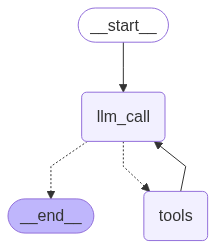

In [83]:
wf

In [84]:
from langchain_core.messages import HumanMessage
final_state = wf.invoke({"messages": HumanMessage("read the csv file customers-100.csv and show its top 2 rows")})

type of datdframe in read csv function is <class 'pandas.core.frame.DataFrame'>
type of datdframe in read csv function is <class 'pandas.core.frame.DataFrame'>


In [85]:
for m in final_state["messages"]:
    m.pretty_print()

================================ Human Message =================================

read the csv file customers-100.csv and show its top 2 rows
================================== Ai Message ==================================
Tool Calls:
  read_csv_file (a3085d42-fa73-46ac-ab61-f18f4059680a)
 Call ID: a3085d42-fa73-46ac-ab61-f18f4059680a
  Args:
    path: customers-100.csv
================================= Tool Message =================================
Name: read_csv_file

    Index      Customer Id First Name Last Name  \
0       1  DD37Cf93aecA6Dc     Sheryl    Baxter   
1       2  1Ef7b82A4CAAD10    Preston    Lozano   
2       3  6F94879bDAfE5a6        Roy     Berry   
3       4  5Cef8BFA16c5e3c      Linda     Olsen   
4       5  053d585Ab6b3159     Joanna    Bender   
..    ...              ...        ...       ...   
95     96  cb8E23e48d22Eae       Karl     Greer   
96     97  CeD220bdAaCfaDf       Lynn  Atkinson   
97     98  28CDbC0dFe4b1Db       Fred    Guerra   
98     99  c23d

In [86]:
final_state["messages"]

[HumanMessage(content='read the csv file customers-100.csv and show its top 2 rows', additional_kwargs={}, response_metadata={}, id='7399c31e-2f6d-4794-9aa4-9708d94f43c3'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'read_csv_file', 'arguments': '{"path": "customers-100.csv"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.0-flash', 'safety_ratings': []}, id='run--6e0fcf9f-e4eb-450b-aa98-e4f887fcb76b-0', tool_calls=[{'name': 'read_csv_file', 'args': {'path': 'customers-100.csv'}, 'id': 'a3085d42-fa73-46ac-ab61-f18f4059680a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 73, 'output_tokens': 13, 'total_tokens': 86, 'input_token_details': {'cache_read': 0}}),
 ToolMessage(content='    Index      Customer Id First Name Last Name  \\\n0       1  DD37Cf93aecA6Dc     Sheryl    Baxter   \n1       2  1Ef7b82A4CAAD10    Preston    Lozano   \n2       3  6F94879bDAfE5a6        R